#  Chargement  et traitement des dataset Input_Space et Output_Space

In [1]:
import pandas as pd
Input_Space = pd.read_excel('Input_Space.xlsx',engine='openpyxl')
Input_Space

,RM_1,RM_2,RM_3,RM_4,BLOC_1,BLOC_2,PR_temp,PR_speed
0,0.5,4.0,3.5,10,18,28,23,50
1,1.0,0.5,5.0,15,18,28,18,40
2,1.5,1.0,2.0,7,18,28,25,70
3,2.0,1.5,3.5,10,18,28,30,25
4,3.5,2.0,0.5,9,18,28,23,80
5,0.5,0.5,1.0,12,18,28,27,90
6,1.0,1.0,1.5,10,18,28,18,50
7,1.5,1.5,2.0,13,18,28,32,40
8,2.0,2.0,5.0,14,18,28,30,70
9,3.5,3.5,4.0,7,18,28,23,25


In [2]:
Output_Space = pd.read_excel('Output_Space.xlsx',engine='openpyxl')
Output_Space

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
0,128.0,25000,6.920819,67.480662,1,2,2,100.0,649.5
1,137.5,27625,11.792500,16.582639,1,1,3,25.0,546.0
2,55.0,39250,4.110698,54.859325,1,2,3,75.0,1009.0
3,120.5,48875,6.890253,99.770620,0,3,3,92.5,23.5
4,72.0,56500,6.259637,13.420144,0,1,5,85.0,1245.5
5,9.5,31625,9.440692,70.877713,1,3,2,35.0,1377.0
6,37.0,27250,6.500000,64.223469,0,2,3,47.5,737.5
7,74.5,45875,10.103749,50.865358,1,2,3,75.0,289.0
8,178.0,48500,10.756962,89.468562,1,3,4,95.0,929.0
9,188.5,55375,3.785819,98.781719,0,3,4,100.0,147.0


# Filtrer les données avec la Variance

In [4]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold() # Threshold default is 0
_ = vt.fit(Input_Space)
var_vector_mask = vt.get_support()
#var_vector_mask 
Input_Space = Input_Space.loc[:, var_vector_mask]
Input_Space

,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed
0,0.5,4.0,3.5,10,23,50
1,1.0,0.5,5.0,15,18,40
2,1.5,1.0,2.0,7,25,70
3,2.0,1.5,3.5,10,30,25
4,3.5,2.0,0.5,9,23,80
5,0.5,0.5,1.0,12,27,90
6,1.0,1.0,1.5,10,18,50
7,1.5,1.5,2.0,13,32,40
8,2.0,2.0,5.0,14,30,70
9,3.5,3.5,4.0,7,23,25


# fonction permettant de multiplier les colonnes entre elles deux a deux

In [5]:
def ft_combinatorial(ft_input):
    from itertools import combinations
    df=ft_input
    cc = list(combinations(df.columns,2))
    df= pd.concat([df[c[1]]*df[c[0]] for c in cc], axis=1, keys=cc)
    df.columns = df.columns.map('*'.join)
    return df

# Creation d'un nouveau dataset input space par interactions

In [6]:
ft=ft_combinatorial(Input_Space)
Input_Space=pd.concat([Input_Space,ft],axis=1,join='inner')
col_names=Input_Space.columns
Input_Space

,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed,RM_1*RM_2,RM_1*RM_3,RM_1*RM_4,RM_1*PR_temp,...,RM_2*RM_3,RM_2*RM_4,RM_2*PR_temp,RM_2*PR_speed,RM_3*RM_4,RM_3*PR_temp,RM_3*PR_speed,RM_4*PR_temp,RM_4*PR_speed,PR_temp*PR_speed
0,0.5,4.0,3.5,10,23,50,2.00,1.75,5.0,11.5,...,14.00,40.0,92.0,200.0,35.0,80.5,175.0,230,500,1150
1,1.0,0.5,5.0,15,18,40,0.50,5.00,15.0,18.0,...,2.50,7.5,9.0,20.0,75.0,90.0,200.0,270,600,720
2,1.5,1.0,2.0,7,25,70,1.50,3.00,10.5,37.5,...,2.00,7.0,25.0,70.0,14.0,50.0,140.0,175,490,1750
3,2.0,1.5,3.5,10,30,25,3.00,7.00,20.0,60.0,...,5.25,15.0,45.0,37.5,35.0,105.0,87.5,300,250,750
4,3.5,2.0,0.5,9,23,80,7.00,1.75,31.5,80.5,...,1.00,18.0,46.0,160.0,4.5,11.5,40.0,207,720,1840
5,0.5,0.5,1.0,12,27,90,0.25,0.50,6.0,13.5,...,0.50,6.0,13.5,45.0,12.0,27.0,90.0,324,1080,2430
6,1.0,1.0,1.5,10,18,50,1.00,1.50,10.0,18.0,...,1.50,10.0,18.0,50.0,15.0,27.0,75.0,180,500,900
7,1.5,1.5,2.0,13,32,40,2.25,3.00,19.5,48.0,...,3.00,19.5,48.0,60.0,26.0,64.0,80.0,416,520,1280
8,2.0,2.0,5.0,14,30,70,4.00,10.00,28.0,60.0,...,10.00,28.0,60.0,140.0,70.0,150.0,350.0,420,980,2100
9,3.5,3.5,4.0,7,23,25,12.25,14.00,24.5,80.5,...,14.00,24.5,80.5,87.5,28.0,92.0,100.0,161,175,575


# # Creation des fakes variables

In [7]:
import numpy as np
Vars=Input_Space.columns
Input_Space[[v + "_fake" for v in Vars]]=Input_Space.iloc[np.random.permutation(Input_Space.index)].reset_index(drop=True)
print(Input_Space.shape)       

(12, 42)


# Application de la standardisation avec “StandardScaler” dans le package #preprocessing.¶

In [8]:
import pandas as pd    
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
Output_scaled = pd.DataFrame(ss.fit_transform(Output_Space),columns =Output_Space.columns)
Output_scaled

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
0,0.626685,-1.340738,-0.150404,0.105718,1.0,-0.346410,-1.441153,1.145618,-0.330863
1,0.805513,-1.165406,1.661278,-1.747360,1.0,-1.732051,-0.480384,-1.338855,-0.550906
2,-0.747473,-0.388932,-1.195432,-0.353795,1.0,-0.346410,-0.480384,0.317460,0.433444
3,0.485504,0.253954,-0.161771,1.281320,-1.0,1.039230,-0.480384,0.897171,-1.661755
4,-0.427463,0.763254,-0.396284,-1.862499,-1.0,-1.732051,1.441153,0.648723,0.936249
5,-1.603968,-0.898232,0.786687,0.229397,1.0,1.039230,-1.441153,-1.007592,1.215821
6,-1.086306,-1.190453,-0.306898,-0.012868,-1.0,-0.346410,-0.480384,-0.593513,-0.143773
7,-0.380403,0.053574,1.033265,-0.499206,1.0,-0.346410,-0.480384,0.317460,-1.097295
8,1.567888,0.228907,1.276182,0.906246,1.0,1.039230,0.480384,0.979986,0.263361
9,1.765541,0.688111,-1.316248,1.245317,-1.0,1.039230,0.480384,1.145618,-1.399191


In [9]:
import pandas as pd    
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
Input_scaled = pd.DataFrame(ss.fit_transform(Input_Space),columns =Input_Space.columns)
Input_scaled

,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed,RM_1*RM_2,RM_1*RM_3,RM_1*RM_4,RM_1*PR_temp,...,RM_2*RM_3_fake,RM_2*RM_4_fake,RM_2*PR_temp_fake,RM_2*PR_speed_fake,RM_3*RM_4_fake,RM_3*PR_temp_fake,RM_3*PR_speed_fake,RM_4*PR_temp_fake,RM_4*PR_speed_fake,PR_temp*PR_speed_fake
0,-1.174440,2.091053,0.650945,-0.122628,-0.320408,-0.401931,-0.236390,-0.718325,-1.358979,-1.182422,...,-0.394810,-0.619358,-0.936380,-0.861037,2.102428,0.699610,0.938089,0.183715,-0.025912,-1.192886
1,-0.822108,-0.788430,1.588305,1.716790,-1.388437,-0.840402,-0.672801,0.130605,-0.472689,-0.996664,...,-0.793776,-0.749749,-0.782688,-0.451019,-0.678737,-0.805099,-0.389823,0.788018,1.730000,1.641858
2,-0.469776,-0.377075,-0.286416,-1.226279,0.106803,0.475010,-0.381860,-0.391814,-0.871519,-0.439389,...,1.101312,1.162654,0.805458,1.107047,1.881701,2.132666,2.748879,1.862333,1.364185,1.094803
3,-0.117444,0.034280,0.650945,-0.122628,1.174831,-1.498107,0.054551,0.653023,-0.029543,0.203619,...,-0.594293,-0.402039,-0.628997,-0.369016,-0.546300,-0.805099,-0.570902,-0.823455,-0.391727,-0.894492
4,0.939552,0.445634,-1.223776,-0.490511,-0.320408,0.913480,1.218316,-0.718325,0.989692,0.789472,...,-0.694034,0.293380,0.327306,1.435061,-1.009828,-1.175305,-0.993419,-0.521304,0.413066,0.663789
5,-1.174440,-0.788430,-0.911322,0.613139,0.534014,1.351951,-0.745537,-1.044837,-1.270350,-1.125266,...,1.899244,0.858408,1.505608,0.246010,0.027591,0.747378,-0.269103,-1.036080,-1.580626,-1.433259
6,-0.822108,-0.377075,-0.598869,-0.122628,-1.388437,-0.401931,-0.527331,-0.783628,-0.915834,-0.996664,...,1.899244,2.205783,1.898375,2.091089,0.336609,0.472709,0.636291,-0.263916,-0.391727,-0.480055
7,-0.469776,0.034280,-0.286416,0.981023,1.602042,-0.840402,-0.163654,-0.391814,-0.073858,-0.139319,...,-0.893517,-1.271314,-1.243763,-1.189051,-0.722882,-1.020057,-0.389823,-0.622021,1.400767,0.299085
8,-0.117444,0.445634,1.588305,1.348907,1.174831,0.475010,0.345493,1.436651,0.679490,0.203619,...,-0.893517,-1.271314,-1.243763,-1.189051,-1.076046,-1.127536,-0.993419,-1.024889,-0.464890,1.194267
9,0.939552,1.679698,0.963398,-1.226279,-0.320408,-1.498107,2.745757,2.481488,0.369288,0.789472,...,-0.494551,-0.662822,-0.389921,-0.041002,-0.590446,-0.255761,0.213774,-0.879409,-0.428308,0.514592


# Fonction permettant de comparer les variables avec leur fakes

In [10]:
def ft_from_fake(ft_input,var_names):
    ft=ft_input
    # print(ft)
    for i in var_names: 
        #print(ft.loc[i,'feature_importance_vals'])
        if  ft.loc[i,'feature_importance_vals'] <= ft.loc[i+"_fake",'feature_importance_vals']:
            ft.loc[i,'feature_importance_vals']=0
          
    ft.drop(ft.tail(len(col_names)).index,inplace = True)
    
    return ft

# Random Forest model and SHAP for Cost prediction

In [11]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y1 = Output_scaled.loc[:,'Cost'].astype(float)
X = Input_scaled
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y1, cv=10, scoring=make_scorer(mean_squared_error))
#mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y1) 
import shap
import numpy as np
##### SHAP explaination
shap_values1 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals1= np.abs(shap_values1).mean(0)
feature_importance1 = pd.DataFrame(list(zip(X,vals1)),columns=['col_name','feature_importance_vals'])
feature_importance1.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance1=feature_importance1.set_index('col_name',drop=True)


Text(0.5, 0, 'Mean SHAP Value')

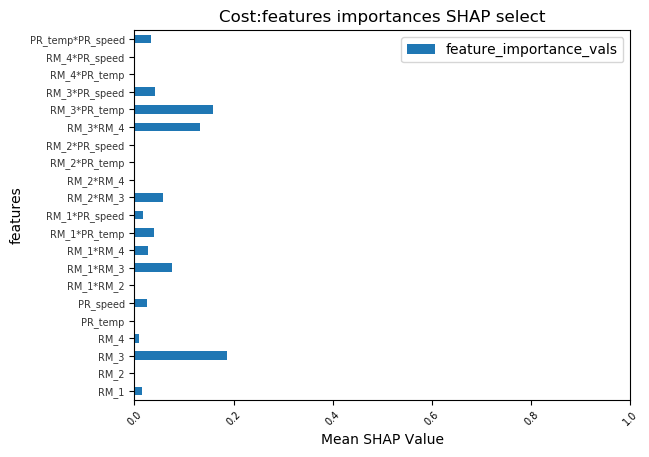

In [12]:
##########  VISUALISATION SHAP VALUES
import matplotlib.pyplot as plt
ft_from_fake(feature_importance1,col_names)
fi_1=1.15*feature_importance1
fi_1.loc[fi_1.feature_importance_vals>1,'feature_importance_vals']=1
fi_1.reset_index()
# Get the Horizontal bar
fi_1.plot(kind='barh')
plt.title("Cost:features importances SHAP select")
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")


# Random Forest model and SHAP for Visco prediction

In [13]:
##################### Random Forest application
Y2 = Output_scaled.loc[:,'Visco'].astype(float)
X = Input_scaled
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y2, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y2) 
##### SHAP explaination
import shap
shap_values2 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals2= np.abs(shap_values2).mean(0)
feature_importance2 = pd.DataFrame(list(zip(X,vals2)),columns=['col_name','feature_importance_vals'])
feature_importance2.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance2=feature_importance2.set_index('col_name',drop=True)

Text(0.5, 0, 'Mean SHAP Value')

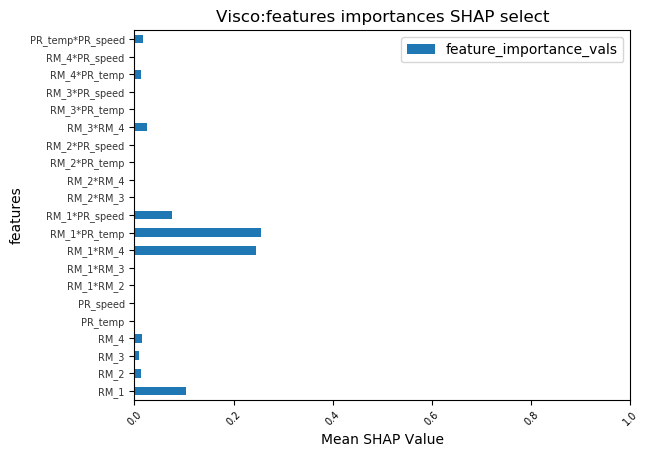

In [14]:
##########  VISUALISATION SHAP VALUES
ft_from_fake(feature_importance2,col_names)
fi_2=1.15*feature_importance2
fi_2.loc[fi_2.feature_importance_vals>1,'feature_importance_vals']=1
fi_2.reset_index()
# Get the Horizontal bar
fi_2.plot(kind='barh')
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.title("Visco:features importances SHAP select")
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Ph prediction

In [15]:
##################### Random Forest application
Y3 = Output_scaled.loc[:,'Ph'].astype(float)  
X = Input_scaled
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y3, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y3) 
mean_mse, std_mse = np.mean(Score), np.std(Score)
##### SHAP explaination
import shap
shap_values3 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals3= np.abs(shap_values3).mean(0)
feature_importance3 = pd.DataFrame(list(zip(X,vals3)),columns=['col_name','feature_importance_vals'])
feature_importance3.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance3=feature_importance3.set_index('col_name',drop=True)

Text(0.5, 0, 'Mean SHAP Value')

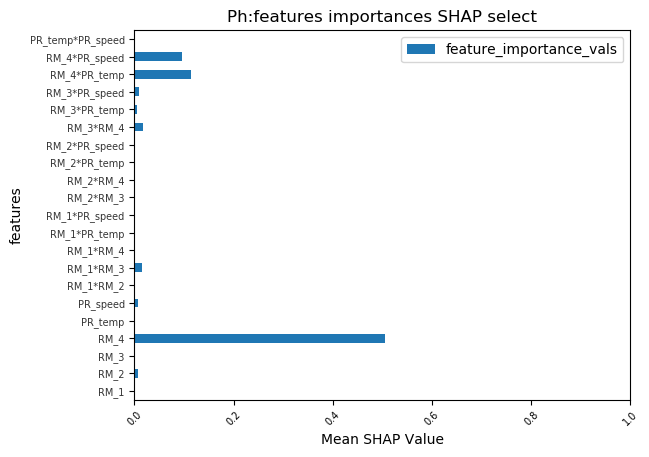

In [16]:
##########  VISUALISATION SHAP VALUES
ft_from_fake(feature_importance3,col_names)
fi_3=1.15*feature_importance3
fi_3.loc[fi_3.feature_importance_vals>1,'feature_importance_vals']=1
fi_3.reset_index()
# Get the Horizontal bar
fi_3.plot(kind='barh')
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.title("Ph:features importances SHAP select")
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Rheo prediction¶

In [17]:
##################### Random Forest application
Y4 =Output_scaled.loc[:,'Rheo'].astype(float)
X = Input_scaled
# 10*Output_Space.loc[:,'Rheo'].astype(float)
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y4, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y4) 
import shap
##### SHAP explaination
shap_values4 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals4= np.abs(shap_values4).mean(0)
feature_importance4 = pd.DataFrame(list(zip(X,vals4)),columns=['col_name','feature_importance_vals'])
feature_importance4.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance4=feature_importance4.set_index('col_name',drop=True)

Text(0.5, 0, 'Mean SHAP Value')

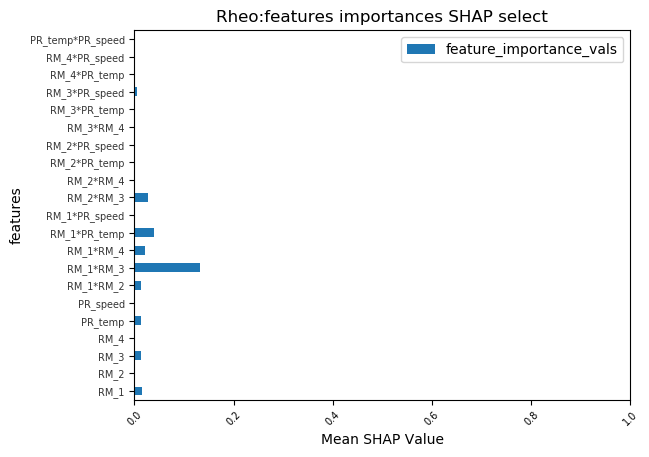

In [18]:
##########  VISUALISATION SHAP VALUES
ft_from_fake(feature_importance4,col_names)
fi_4=1.15*feature_importance4
fi_4.loc[fi_4.feature_importance_vals>1,'feature_importance_vals']=1
fi_4.reset_index()
# Get the Horizontal bar
fi_4.plot(kind='barh')
plt.title("Rheo:features importances SHAP select")
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Stability prediction

In [19]:
##################### Random Forest application
Y5 = Output_scaled.loc[:,'Stability'].astype(float)
X = Input_scaled
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y5, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y5) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals5= np.abs(shap_values5).mean(0)
feature_importance5 = pd.DataFrame(list(zip(X,vals5)),columns=['col_name','feature_importance_vals'])
feature_importance5.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance5=feature_importance5.set_index('col_name',drop=True)

Text(0.5, 0, 'Mean SHAP Value')

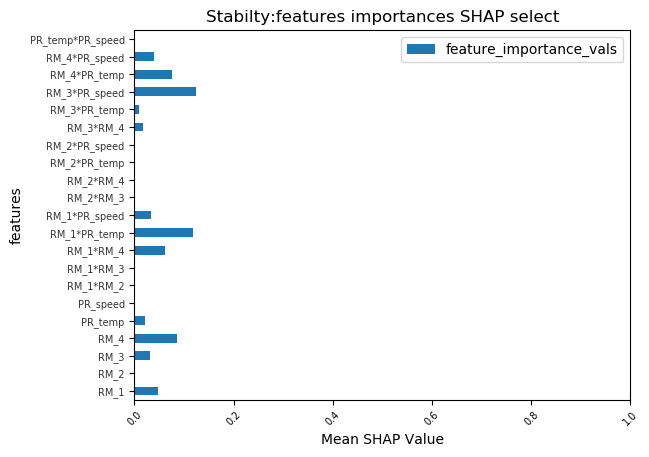

In [20]:
##########  VISUALISATION SHAP VALUES
ft_from_fake(feature_importance5,col_names)
fi_5=1.15*feature_importance5
fi_5.loc[fi_5.feature_importance_vals>1,'feature_importance_vals']=1
fi_5.reset_index()
# Get the Horizontal bar
fi_5.plot(kind='barh')
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.title("Stabilty:features importances SHAP select")
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Texture prediction


In [21]:
##################### Random Forest application
Y6 = Output_scaled.loc[:,'Texture'].astype(float)
X = Input_scaled
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y6, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y6) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals6= np.abs(shap_values6).mean(0)
feature_importance6 = pd.DataFrame(list(zip(X,vals6)),columns=['col_name','feature_importance_vals'])
feature_importance6.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance6=feature_importance6.set_index('col_name',drop=True)

Text(0.5, 0, 'Mean SHAP Value')

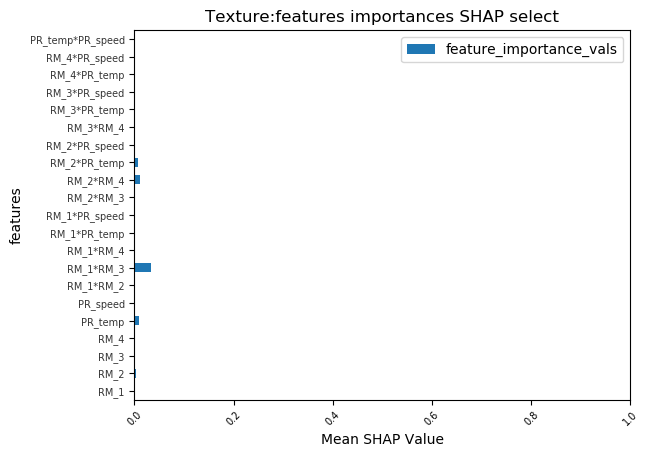

In [22]:
##########  VISUALISATION SHAP VALUES
ft_from_fake(feature_importance6,col_names)
fi_6=1.15*feature_importance6
fi_6.loc[fi_6.feature_importance_vals>1,'feature_importance_vals']=1
fi_6.reset_index()
# Get the Horizontal bar
fi_6.plot(kind='barh')
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.title("Texture:features importances SHAP select")
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Senso1 prediction

In [23]:
##################### Random Forest application
Y7 = Output_scaled.loc[:,'Senso1'].astype(float)
X = Input_scaled
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y7, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y7) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals7= np.abs(shap_values7).mean(0)
feature_importance7 = pd.DataFrame(list(zip(X,vals7)),columns=['col_name','feature_importance_vals'])
feature_importance7.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance7=feature_importance7.set_index('col_name',drop=True)


Text(0.5, 0, 'Mean SHAP Value')

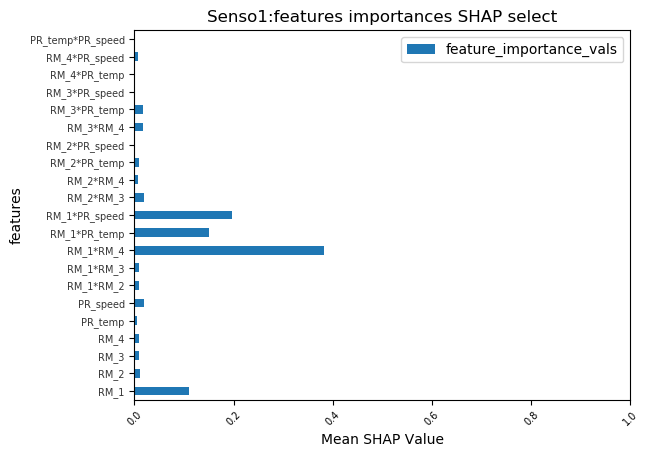

In [24]:
##########  VISUALISATION SHAP VALUES
ft_from_fake(feature_importance7,col_names)
fi_7=1.15*feature_importance7
fi_7.loc[fi_7.feature_importance_vals>1,'feature_importance_vals']=1
fi_7.reset_index()
# Get the Horizontal bar
fi_7.plot(kind='barh')
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.title("Senso1:features importances SHAP select")
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Naturality prediction

In [25]:
##################### Random Forest application
Y8 = Output_scaled.loc[:,'Naturality'].astype(float)
X = Input_scaled
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y8) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals8= np.abs(shap_values8).mean(0)
feature_importance8 = pd.DataFrame(list(zip(X,vals8)),columns=['col_name','feature_importance_vals'])
feature_importance8.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance8=feature_importance8.set_index('col_name',drop=True)

Text(0.5, 0, 'Mean SHAP Value')

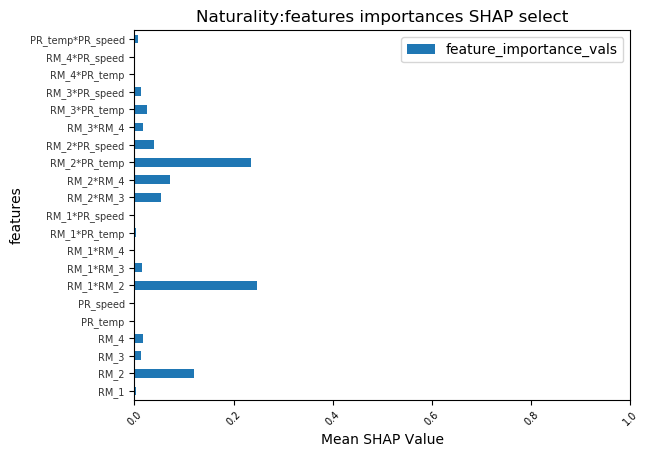

In [26]:
##########  VISUALISATION SHAP VALUES
ft_from_fake(feature_importance8,col_names)
fi_8=1.15*feature_importance8
fi_8.loc[fi_8.feature_importance_vals>1,'feature_importance_vals']=1
fi_8.reset_index()
# Get the Horizontal bar
fi_8.plot(kind='barh')
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.title("Naturality:features importances SHAP select")
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Microbio30days prediction¶

In [27]:
##################### Random Forest application
Y9 = Output_scaled.loc[:,'Microbio30days'].astype(float)
X = Input_scaled
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y9) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9 = shap.TreeExplainer(model).shap_values(X)
########################### SHAP VALUES IMPORTANCE
vals9= np.abs(shap_values9).mean(0)
feature_importance9 = pd.DataFrame(list(zip(X,vals9)),columns=['col_name','feature_importance_vals'])
feature_importance9.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance9=feature_importance9.set_index('col_name',drop=True)

Text(0.5, 0, 'Mean SHAP Value')

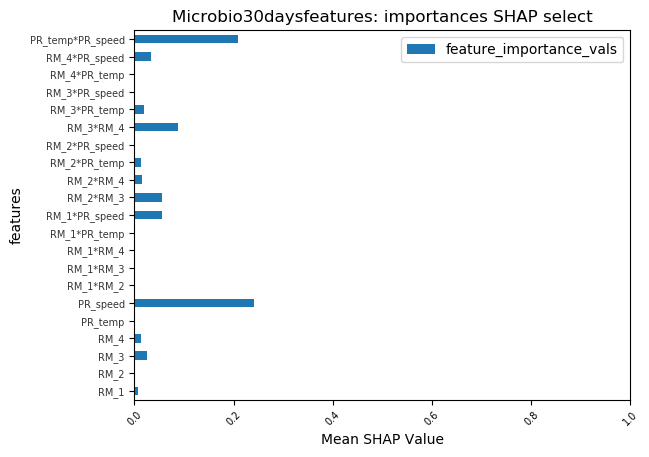

In [28]:
##########  VISUALISATION SHAP VALUES
ft_from_fake(feature_importance9,col_names)
fi_9=1.15*feature_importance9
fi_9.loc[fi_9.feature_importance_vals>1,'feature_importance_vals']=1
fi_9.reset_index()
# Get the Horizontal bar
fi_9.plot(kind='barh')
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=7,color ='0.2')
plt.title("Microbio30daysfeatures: importances SHAP select")
plt.xlim([0, 1])
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Summary plot 

In [339]:
Output=pd.concat([fi_1,fi_2,fi_3,fi_4,fi_5,fi_6,fi_7,fi_8,fi_9],axis=1,join='inner',sort=False)
Output.columns=Output_Space.columns
Output

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
col_name,,,,,,,,,
RM_1,0.015721,0.104952,0.000000,0.015423,0.047209,0.000000,0.110894,0.002997,0.006397
RM_2,0.000000,0.014204,0.008032,0.000000,0.000000,0.002833,0.011243,0.119176,0.000000
RM_3,0.187278,0.008732,0.000000,0.012913,0.031721,0.000000,0.009654,0.012925,0.025222
RM_4,0.009134,0.015451,0.506070,0.000000,0.085957,0.000000,0.008477,0.017035,0.013045
PR_temp,0.001312,0.000000,0.000000,0.013705,0.021403,0.008299,0.005551,0.000000,0.000000
PR_speed,0.025463,0.000000,0.006718,0.000000,0.000000,0.000000,0.019911,0.000000,0.240755
RM_1*RM_2,0.000000,0.000000,0.000000,0.013472,0.000000,0.000000,0.009902,0.247563,0.000000
RM_1*RM_3,0.075899,0.000000,0.015674,0.131280,0.000000,0.032993,0.008287,0.015205,0.000000
RM_1*RM_4,0.026775,0.244719,0.000000,0.021697,0.061812,0.000000,0.382452,0.000000,0.000000


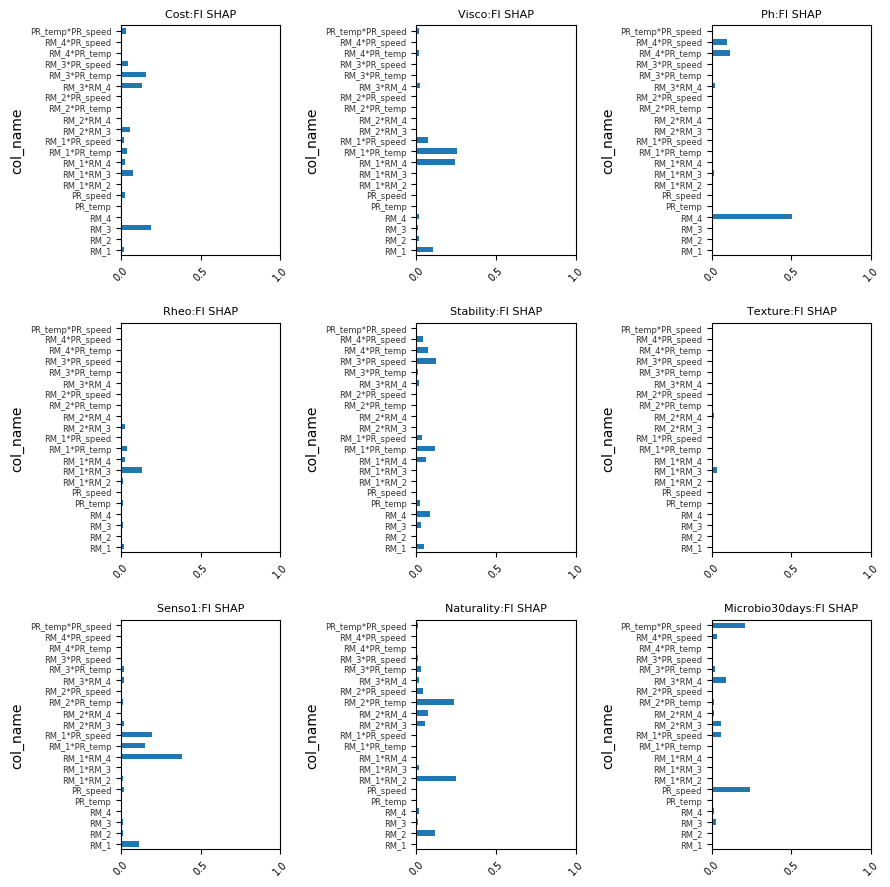

In [352]:
import pandas as pd 
import matplotlib.pyplot as plt 
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(Output.columns):
    ax = fig.add_subplot(3, 3, i+1)
    Output[col].plot(kind='barh')
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 1])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)   
plt.show()


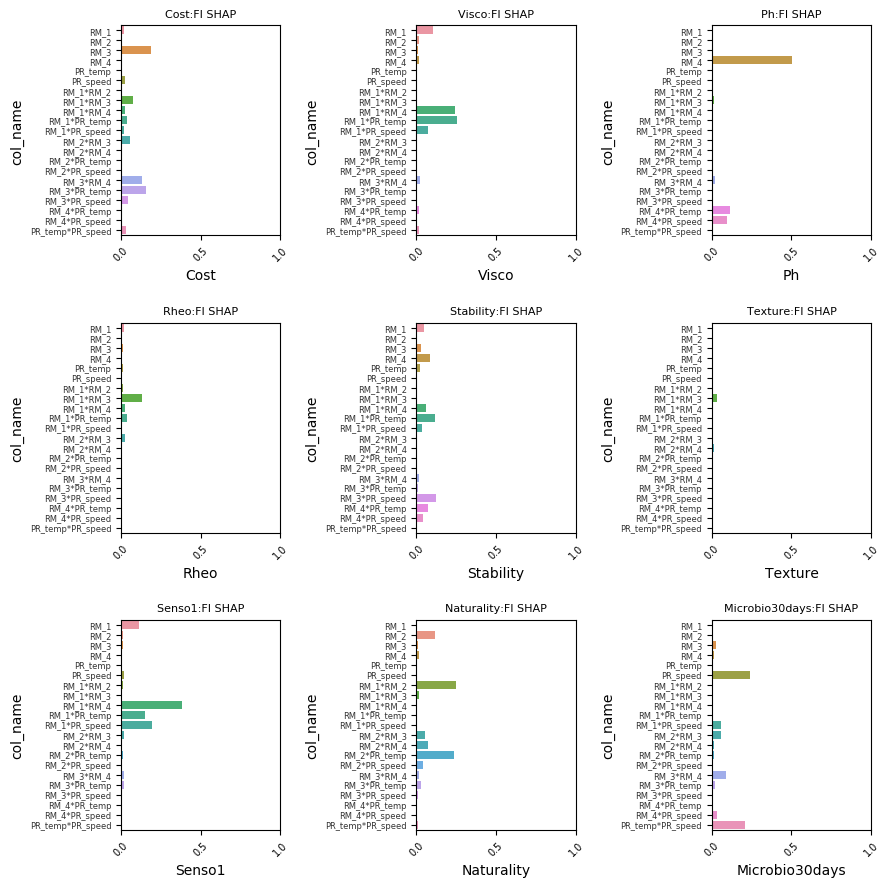

In [366]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(Output.columns):
    ax = fig.add_subplot(3, 3, i+1)
    sns.barplot(x=Output[col], y=Output.index)
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 1])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)
plt.show()


# Summary plot variable ranking

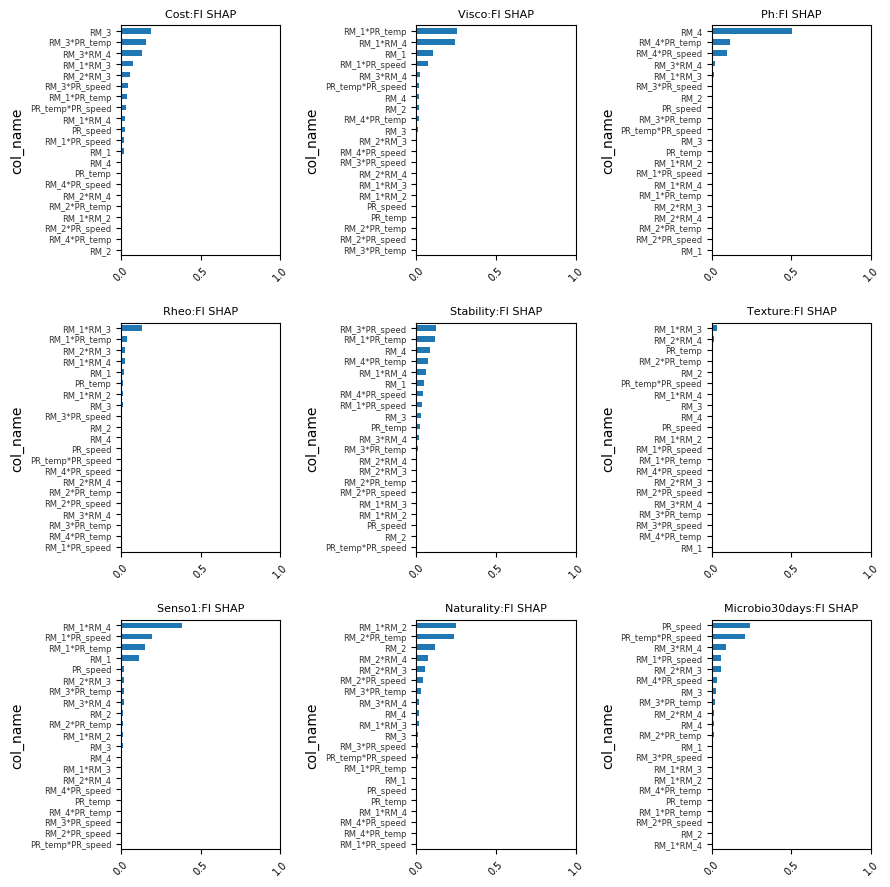

In [353]:
import pandas as pd 
import matplotlib.pyplot as plt 
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(Output.columns):
    ax = fig.add_subplot(3, 3, i+1)
    Output[col].sort_values().plot(kind='barh')
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 1])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)   
plt.show()


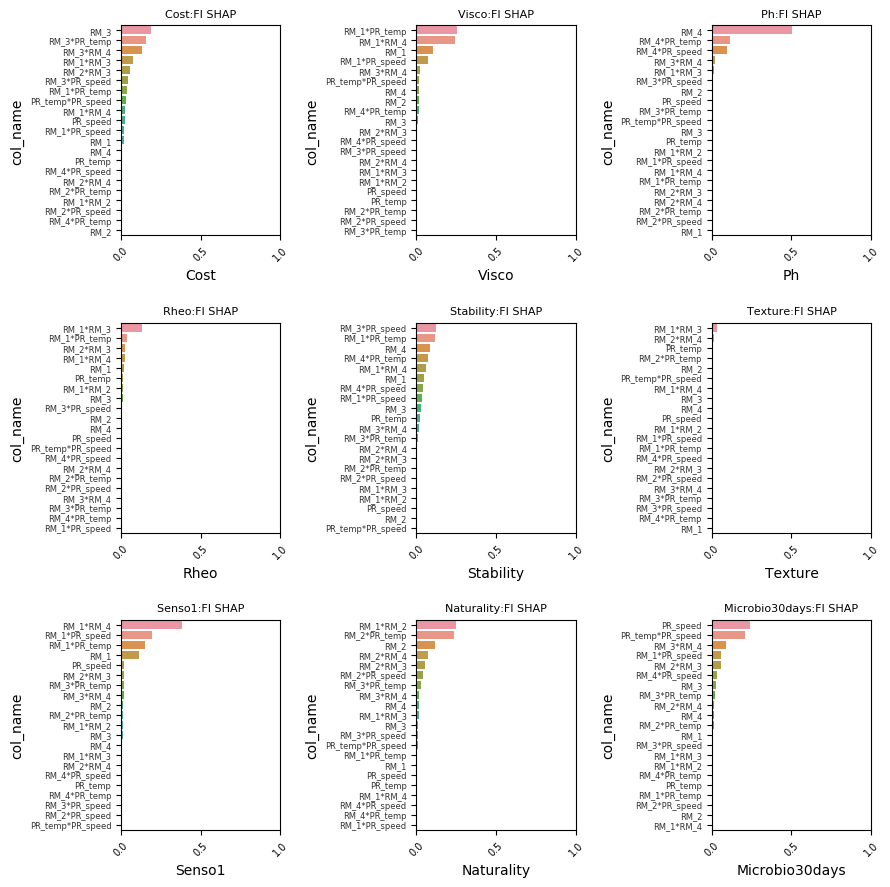

In [365]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(Output.columns):
    ax = fig.add_subplot(3, 3, i+1)
    sns.barplot(x=Output[col], y=Output.index, order=Output[col].sort_values(ascending = False).index)
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 1])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
######################## feature importance SHAP
#plt.suptitle("Tous mes graphes", fontsize=16) #Affiche un titre pour la figure
plt.figure(figsize = (7, 7))
plt.subplot(331)
plt.barh(col_names,fi_1["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Cost:FI SHAP",fontsize=8)
plt.subplot(332)
plt.barh(col_names,fi_2["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Visco:FI SHAP ",fontsize=8)
plt.subplot(333)
plt.barh(col_names,fi_3["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Ph:FI SHAP",fontsize=8)
plt.subplot(334)
plt.barh(col_names,fi_4["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Rheo:FI SHAP",fontsize=8)
plt.subplot(335)
plt.barh(col_names,fi_5["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Stability:FI SHAP",fontsize=8)
plt.subplot(336)
plt.barh(col_names,fi_6["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Texture:FI SHAP",fontsize=8)
plt.subplot(337)
plt.barh(col_names,fi_7["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Senso1:FI SHAP",fontsize=8)
plt.subplot(338)
plt.barh(col_names,fi_8["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Naturality:FI SHAP",fontsize=8)
plt.subplot(339)
plt.barh(col_names,fi_9["feature_importance_vals"])
plt.xlim([0, 1])
plt.xticks(fontsize=7)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Microbio30days:FI SHAP",fontsize=8)
#plt.suptitle("Microbio30days:feature Importances SHAP")
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=1)
plt.tight_layout(pad=1,h_pad=1.4)
plt.show()